# Portfólio 3: Modelos de Suavização Exponencial
**Objetivo:** Implementar modelos SES, Holt e Holt-Winters para previsão de séries temporais.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, Holt, ExponentialSmoothing

# Configuração visual profissional
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.titleweight'] = 'semibold'
plt.style.use('ggplot')

## 1. Exercício 1: Suavização Exponencial Simples (SES)
Aplicado à série de vendas de produtos elétricos (1975-1976).
O modelo SES é ideal para séries localmente constantes.

Previsão para Maio/1976 (SES): 53.06


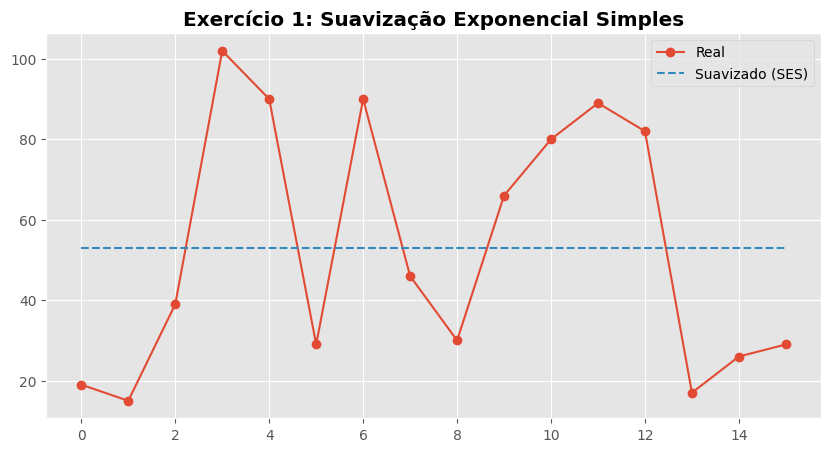

In [6]:
# Dados do Exercício 1 - Vendas de produtos elétricos
vendas_eletricos = [
    19, 15, 39, 102, 90, 29, 90, 46, 30, 66, 80, 89, # 1975
    82, 17, 26, 29                                   # 1976 (Jan-Abr)
]

df_ses = pd.DataFrame(vendas_eletricos, columns=['Vendas'])

# Ajuste do modelo SES (α escolhido automaticamente pelo statsmodels)
model_ses = SimpleExpSmoothing(df_ses['Vendas'], initialization_method="estimated").fit()
df_ses['Previsao'] = model_ses.fittedvalues

# Previsão para Maio/1976 (h=1)
forecast_maio = model_ses.forecast(1)
print(f"Previsão para Maio/1976 (SES): {forecast_maio.values[0]:.2f}")

plt.figure(figsize=(10, 5))
plt.plot(df_ses['Vendas'], label='Real', marker='o')
plt.plot(df_ses['Previsao'], label='Suavizado (SES)', linestyle='--')
plt.title('Exercício 1: Suavização Exponencial Simples')
plt.legend()
plt.show()

## 2. Exercício 2: Método de Holt (Tendência Linear)
Aplicado à série de vendas de óleo lubrificante.
Este método utiliza uma constante para o nível (A) e outra para a tendência (C).

In [3]:
# Dados do Exercício 2 - Vendas de óleo lubrificante em 1977
oleo_1977 = [538, 570, 600, 565, 485, 604, 527, 603, 604, 790, 714, 653]

# Ajuste do Método de Holt (Suavização Exponencial de Holt - SEH)
model_holt = Holt(oleo_1977, initialization_method="estimated").fit()
forecast_1978 = model_holt.forecast(7) # Previsão Jan-Jul 1978

print("Previsões Holt para 1978 (Jan a Jul):")
months = ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 'Jul']
for m, f in zip(months, forecast_1978):
    print(f"{m}/1978: {f:.2f}")

Previsões Holt para 1978 (Jan a Jul):
Jan/1978: 703.58
Fev/1978: 718.83
Mar/1978: 734.09
Abr/1978: 749.34
Mai/1978: 764.60
Jun/1978: 779.85
Jul/1978: 795.11


## 3. Exercício 3: Método de Holt-Winters (Tendência e Sazonalidade)
Aplicado à série de vendas de refrigerantes (Sazonalidade mensal s=12).

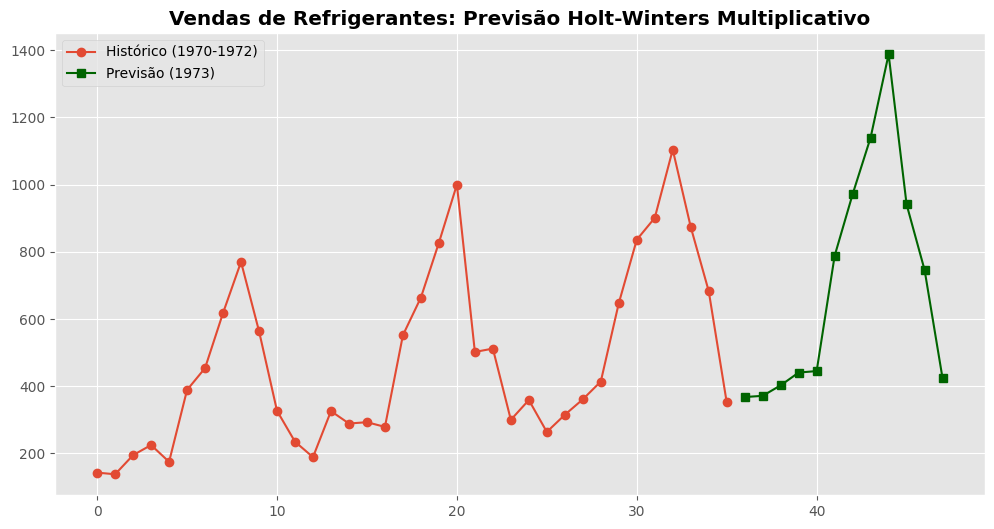

In [4]:
# Dados do Exercício 3 - Vendas de refrigerantes de 1970 a 1972
refrigerantes = [
    143, 138, 195, 225, 175, 389, 454, 618, 770, 564, 327, 235, # 1970
    189, 326, 289, 293, 279, 552, 664, 827, 1000, 502, 512, 300, # 1971
    359, 264, 315, 361, 414, 647, 836, 901, 1104, 874, 683, 352  # 1972
]

# Ajuste do modelo Holt-Winters Multiplicativo
# Justificativa: A amplitude da sazonalidade aumenta conforme o nível da série cresce
model_hw = ExponentialSmoothing(
    refrigerantes, 
    trend='add', 
    seasonal='mul', 
    seasonal_periods=12
).fit()

# Previsão para os 12 meses de 1973
forecast_1973 = model_hw.forecast(12)

plt.figure(figsize=(12, 6))
plt.plot(np.arange(len(refrigerantes)), refrigerantes, label='Histórico (1970-1972)', marker='o')
plt.plot(np.arange(len(refrigerantes), len(refrigerantes)+12), forecast_1973, 
         label='Previsão (1973)', marker='s', color='darkgreen')
plt.title('Vendas de Refrigerantes: Previsão Holt-Winters Multiplicativo')
plt.legend()
plt.show()

## 4. Análise de Resíduos
Conforme solicitado nos itens (b) dos exercícios do portfólio.

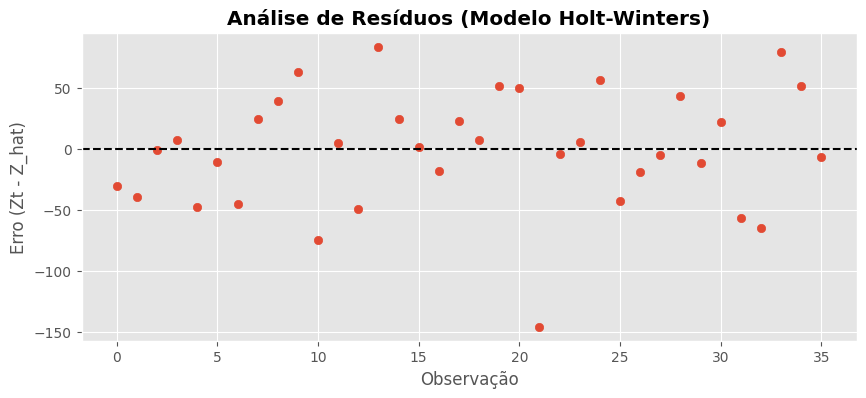

In [5]:
residuos = model_hw.resid

plt.figure(figsize=(10, 4))
plt.scatter(range(len(residuos)), residuos)
plt.axhline(0, color='black', linestyle='--')
plt.title('Análise de Resíduos (Modelo Holt-Winters)')
plt.xlabel('Observação')
plt.ylabel('Erro (Zt - Z_hat)')
plt.show()